# Notebook 04 Results Analysis & Error Analysis

Loads all transfer matrices from `/results/`, synthesises a unified comparison table, produces final visualisations, and performs structured error analysis on the worst-performing cross-category transfer pairs.

In [1]:
!pip install scikit-learn pandas numpy matplotlib seaborn joblib transformers torch -q

In [2]:
CATEGORIES = [
    "Electronics",
    "Books",
    "Clothing_Shoes_and_Jewelry",
    "Home_and_Kitchen",
    "Toys_and_Games",
]

CATEGORY_LABELS = [
    "Electronics", "Books", "Clothing", "Home & Kitchen", "Toys"
]

FILE_STEMS = {
    "Electronics":                "electronics",
    "Books":                      "books",
    "Clothing_Shoes_and_Jewelry": "clothing",
    "Home_and_Kitchen":           "home_kitchen",
    "Toys_and_Games":             "toys",
}

ERROR_SAMPLE_SIZE = 15
RANDOM_SEED       = 104
MAX_LENGTH        = 128
EVAL_BATCH_SIZE   = 32
DRIVE_BASE        = "/content/drive/MyDrive/cross-category-sentiment-robustness"

In [3]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import torch
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score, cohen_kappa_score,
)
from transformers import (
    RobertaTokenizerFast, RobertaForSequenceClassification,
    DistilBertTokenizerFast, DistilBertForSequenceClassification,
    Trainer, TrainingArguments,
)
from torch.utils.data import Dataset
from google.colab import drive

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

drive.mount("/content/drive")
DATA_DIR    = f"{DRIVE_BASE}/data"
MODELS_DIR  = f"{DRIVE_BASE}/models"
RESULTS_DIR = f"{DRIVE_BASE}/results"
FIGURES_DIR = f"{DRIVE_BASE}/figures"

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

Mounted at /content/drive


## 1  Load transfer matrices

In [4]:
logreg_acc = pd.read_csv(f"{RESULTS_DIR}/baseline_transfer_matrix_logreg.csv",  index_col=0)
svm_acc    = pd.read_csv(f"{RESULTS_DIR}/baseline_transfer_matrix_svm.csv",     index_col=0)
rob_acc    = pd.read_csv(f"{RESULTS_DIR}/roberta_transfer_matrix.csv",          index_col=0)
rob_f1     = pd.read_csv(f"{RESULTS_DIR}/roberta_transfer_matrix_f1.csv",       index_col=0)
distil_acc = pd.read_csv(f"{RESULTS_DIR}/distilbert_transfer_matrix.csv",       index_col=0)
distil_f1  = pd.read_csv(f"{RESULTS_DIR}/distilbert_transfer_matrix_f1.csv",    index_col=0)

model_mats = {"LogReg": logreg_acc, "SVM": svm_acc, "RoBERTa": rob_acc, "DistilBERT": distil_acc}
print("Matrices loaded.")

Matrices loaded.


## 2  Unified comparison table

In [5]:
rows = []
labels = CATEGORY_LABELS

for i, src in enumerate(labels):
    for j, tgt in enumerate(labels):
        rows.append({
            "Source":         src,
            "Target":         tgt,
            "In-domain":      i == j,
            "LogReg acc":     float(logreg_acc.iloc[i, j]),
            "SVM acc":        float(svm_acc.iloc[i, j]),
            "RoBERTa acc":    float(rob_acc.iloc[i, j]),
            "DistilBERT acc": float(distil_acc.iloc[i, j]),
        })

unified = pd.DataFrame(rows)
unified.to_csv(f"{RESULTS_DIR}/final_summary_table.csv", index=False)

print()
print("Full comparison table (first 15 rows):")
print(unified.head(15).to_string(index=False))


Full comparison table (first 15 rows):
     Source         Target  In-domain  LogReg acc  SVM acc  RoBERTa acc  DistilBERT acc
Electronics    Electronics       True    0.904000 0.906667     0.754667        0.930667
Electronics          Books      False    0.821333 0.809333     0.662667        0.842667
Electronics       Clothing      False    0.846667 0.848000     0.694667        0.889333
Electronics Home & Kitchen      False    0.894667 0.885333     0.709333        0.896000
Electronics           Toys      False    0.873333 0.870667     0.714667        0.925333
      Books    Electronics      False    0.805333 0.804000     0.673333        0.876000
      Books          Books       True    0.912000 0.912000     0.718667        0.917333
      Books       Clothing      False    0.794667 0.797333     0.660000        0.857333
      Books Home & Kitchen      False    0.809333 0.806667     0.633333        0.850667
      Books           Toys      False    0.850667 0.850667     0.689333        0

## 3  Aggregate statistics

In [6]:
stats_rows = []
for name, mat in model_mats.items():
    m = mat.values.astype(float)
    n = m.shape[0]
    diag = np.diag(m)
    off  = m[~np.eye(n, dtype=bool)]

    best_pair  = np.unravel_index(np.ma.masked_array(m, np.eye(n, dtype=bool)).argmax(), m.shape)
    worst_pair = np.unravel_index(np.ma.masked_array(m, np.eye(n, dtype=bool)).argmin(), m.shape)

    stats_rows.append({
        "Model":                name,
        "Avg in-domain acc":    f"{diag.mean():.3f}",
        "Avg cross-domain acc": f"{off.mean():.3f}",
        "Avg degradation":      f"{diag.mean() - off.mean():.3f}",
        "Best transfer pair":   f"{labels[best_pair[0]]} -> {labels[best_pair[1]]} ({m[best_pair]:.3f})",
        "Worst transfer pair":  f"{labels[worst_pair[0]]} -> {labels[worst_pair[1]]} ({m[worst_pair]:.3f})",
    })

stats_df = pd.DataFrame(stats_rows)
print(stats_df.to_string(index=False))

     Model Avg in-domain acc Avg cross-domain acc Avg degradation                    Best transfer pair             Worst transfer pair
    LogReg             0.904                0.838           0.066 Electronics -> Home & Kitchen (0.895) Home & Kitchen -> Books (0.773)
       SVM             0.911                0.847           0.064    Clothing -> Home & Kitchen (0.900)       Books -> Clothing (0.797)
   RoBERTa             0.725                0.656           0.069              Clothing -> Toys (0.732) Home & Kitchen -> Books (0.540)
DistilBERT             0.920                0.888           0.032        Home & Kitchen -> Toys (0.929)    Electronics -> Books (0.843)


## 4  Transfer matrix heatmaps (all four models)

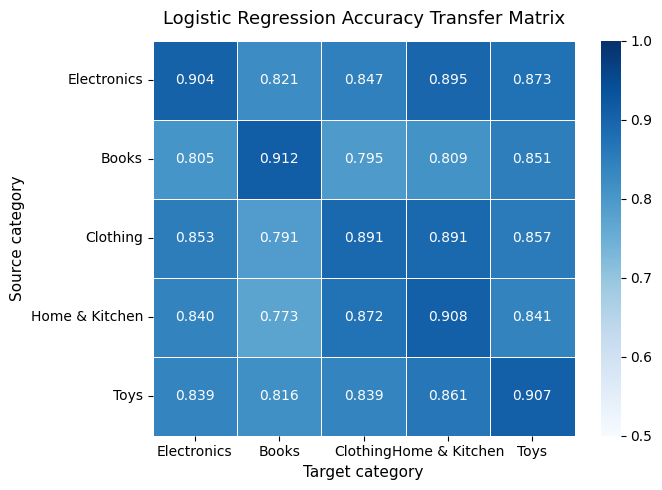

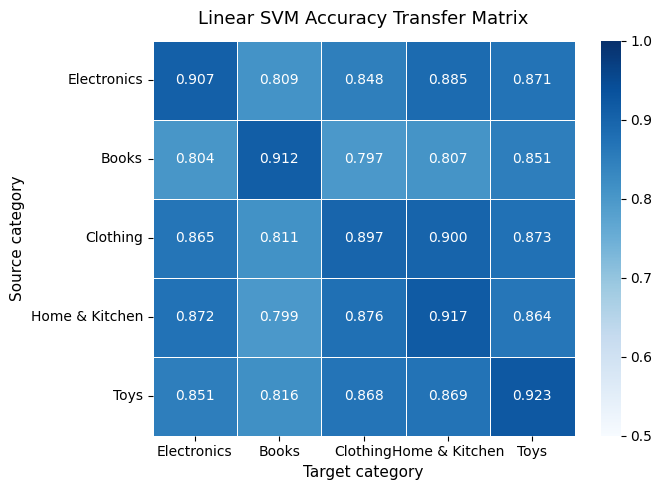

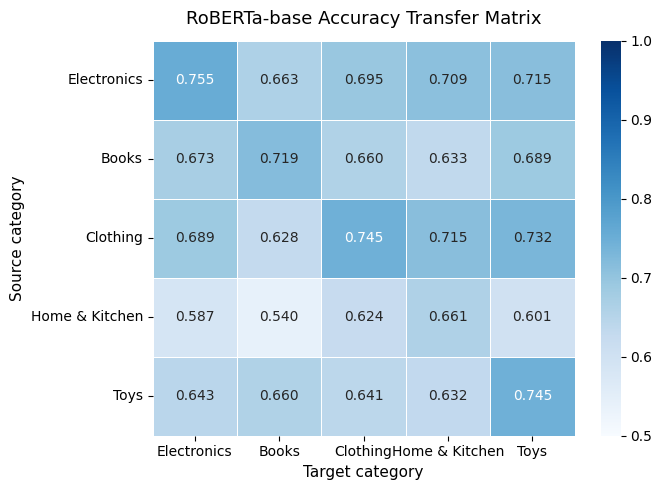

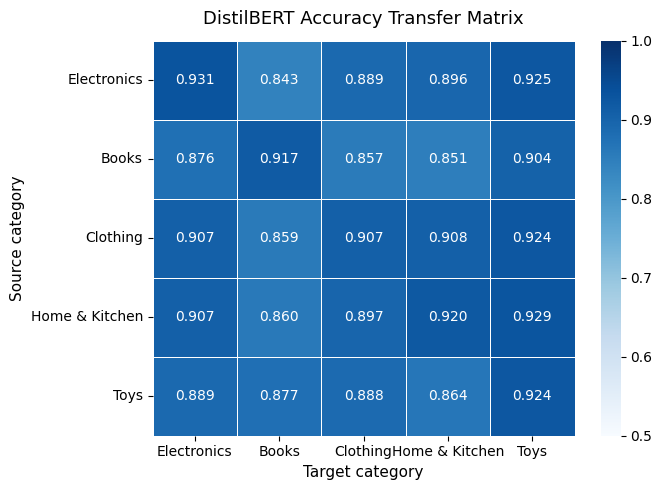

In [7]:
def plot_heatmap(mat: pd.DataFrame, title: str, filename: str):
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(
        mat.astype(float), annot=True, fmt=".3f",
        cmap="Blues", vmin=0.5, vmax=1.0,
        linewidths=0.5, ax=ax,
        xticklabels=mat.columns, yticklabels=mat.index,
    )
    ax.set_xlabel("Target category", fontsize=11)
    ax.set_ylabel("Source category", fontsize=11)
    ax.set_title(title, fontsize=13, pad=12)
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/{filename}", dpi=150)
    plt.show()

plot_heatmap(logreg_acc, "Logistic Regression Accuracy Transfer Matrix", "heatmap_logreg.png")
plot_heatmap(svm_acc,    "Linear SVM Accuracy Transfer Matrix",          "heatmap_svm.png")
plot_heatmap(rob_acc,    "RoBERTa-base Accuracy Transfer Matrix",        "heatmap_roberta.png")
plot_heatmap(distil_acc, "DistilBERT Accuracy Transfer Matrix",          "heatmap_distilbert.png")

## 5  Per-category accuracy tables

In [8]:
for i, src in enumerate(CATEGORY_LABELS):
    rows_cat = []
    for j, tgt in enumerate(CATEGORY_LABELS):
        rows_cat.append({
            "Target":     tgt,
            "LogReg":     f"{float(logreg_acc.iloc[i,j]):.3f}",
            "SVM":        f"{float(svm_acc.iloc[i,j]):.3f}",
            "RoBERTa":    f"{float(rob_acc.iloc[i,j]):.3f}",
            "DistilBERT": f"{float(distil_acc.iloc[i,j]):.3f}",
        })
    tbl = pd.DataFrame(rows_cat)

    print()
    print(f"Source: {src}")
    print(tbl.to_string(index=False))


Source: Electronics
        Target LogReg   SVM RoBERTa DistilBERT
   Electronics  0.904 0.907   0.755      0.931
         Books  0.821 0.809   0.663      0.843
      Clothing  0.847 0.848   0.695      0.889
Home & Kitchen  0.895 0.885   0.709      0.896
          Toys  0.873 0.871   0.715      0.925

Source: Books
        Target LogReg   SVM RoBERTa DistilBERT
   Electronics  0.805 0.804   0.673      0.876
         Books  0.912 0.912   0.719      0.917
      Clothing  0.795 0.797   0.660      0.857
Home & Kitchen  0.809 0.807   0.633      0.851
          Toys  0.851 0.851   0.689      0.904

Source: Clothing
        Target LogReg   SVM RoBERTa DistilBERT
   Electronics  0.853 0.865   0.689      0.907
         Books  0.791 0.811   0.628      0.859
      Clothing  0.891 0.897   0.745      0.907
Home & Kitchen  0.891 0.900   0.715      0.908
          Toys  0.857 0.873   0.732      0.924

Source: Home & Kitchen
        Target LogReg   SVM RoBERTa DistilBERT
   Electronics  0.840 0.872  

## 6  Confusion matrices worst transfer pair per model


LogReg worst pair: Home & Kitchen -> Books


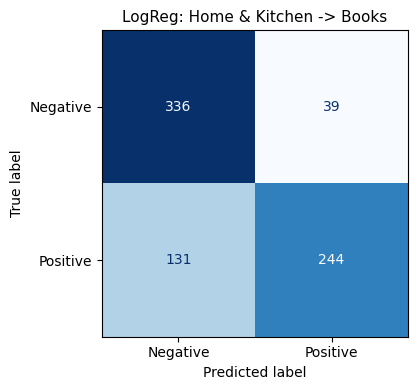


SVM worst pair: Books -> Clothing


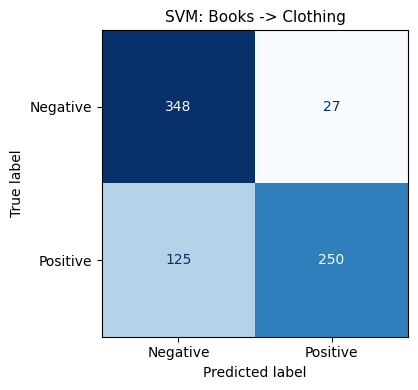

In [9]:
def worst_pair(mat: pd.DataFrame):
    m = mat.values.astype(float)
    n = m.shape[0]
    masked = np.ma.masked_array(m, np.eye(n, dtype=bool))
    idx = np.unravel_index(masked.argmin(), m.shape)
    return idx[0], idx[1]   # source_idx, target_idx


def get_predictions_baseline(clf_name: str, src_idx: int, tgt_idx: int):
    src_stem = FILE_STEMS[CATEGORIES[src_idx]]
    tgt_stem = FILE_STEMS[CATEGORIES[tgt_idx]]
    model_dir = f"{MODELS_DIR}/{clf_name}_{src_stem}"
    vec = joblib.load(f"{model_dir}/tfidf_vectoriser.joblib")
    clf = joblib.load(f"{model_dir}/{clf_name}_classifier.joblib")
    df_test = pd.read_csv(f"{DATA_DIR}/{tgt_stem}_test.csv")
    df_test["text"] = df_test["text"].fillna("").str.lower().str.strip()
    X = vec.transform(df_test["text"])
    return df_test, df_test["label"].values, clf.predict(X)


def plot_confusion(y_true, y_pred, title: str, filename: str):
    cm  = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title, fontsize=11)
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/{filename}", dpi=150)
    plt.show()


for clf_name, mat, label in [
    ("logreg", logreg_acc, "LogReg"),
    ("svm",    svm_acc,    "SVM"),
]:
    si, ti = worst_pair(mat)
    src_label = CATEGORY_LABELS[si]
    tgt_label = CATEGORY_LABELS[ti]
    print()
    print(f"{label} worst pair: {src_label} -> {tgt_label}")
    df_test, y_true, y_pred = get_predictions_baseline(clf_name, si, ti)
    plot_confusion(
        y_true, y_pred,
        f"{label}: {src_label} -> {tgt_label}",
        f"confusion_matrix_worst_{clf_name}.png"
    )

### Confusion matrix: RoBERTa worst pair

RoBERTa worst pair: Home & Kitchen -> Books


Loading weights:   0%|          | 0/201 [00:01<?, ?it/s]

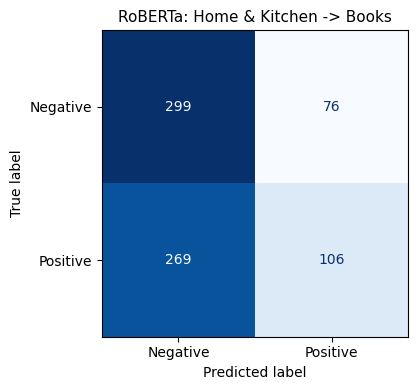

In [10]:
class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding="max_length",
            max_length=max_length, return_tensors="pt"
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

si_rob, ti_rob = worst_pair(rob_acc)
src_stem = FILE_STEMS[CATEGORIES[si_rob]]
tgt_stem = FILE_STEMS[CATEGORIES[ti_rob]]

print(f"RoBERTa worst pair: {CATEGORY_LABELS[si_rob]} -> {CATEGORY_LABELS[ti_rob]}")

tokenizer_rob = RobertaTokenizerFast.from_pretrained(f"{MODELS_DIR}/roberta_{src_stem}")
model_rob = RobertaForSequenceClassification.from_pretrained(f"{MODELS_DIR}/roberta_{src_stem}")

df_tgt = pd.read_csv(f"{DATA_DIR}/{tgt_stem}_test.csv")
df_tgt["text"] = df_tgt["text"].fillna("").astype(str)
test_ds = ReviewDataset(df_tgt["text"], df_tgt["label"], tokenizer_rob, MAX_LENGTH)

trainer_rob = Trainer(
    model=model_rob,
    args=TrainingArguments(
        output_dir="/tmp/eval",
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        fp16=torch.cuda.is_available(),
        report_to="none",
    ),
)
out = trainer_rob.predict(test_ds)
rob_preds = np.argmax(out.predictions, axis=-1)
rob_true  = df_tgt["label"].values

plot_confusion(
    rob_true, rob_preds,
    f"RoBERTa: {CATEGORY_LABELS[si_rob]} -> {CATEGORY_LABELS[ti_rob]}",
    "confusion_matrix_worst_roberta.png"
)

### Confusion matrix: DistilBERT worst pair

DistilBERT worst pair: Electronics -> Books


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

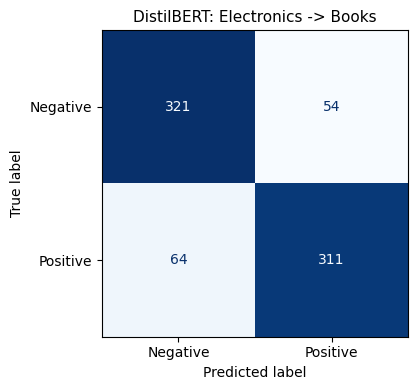

In [11]:
si_distil, ti_distil = worst_pair(distil_acc)
src_stem_distil = FILE_STEMS[CATEGORIES[si_distil]]
tgt_stem_distil = FILE_STEMS[CATEGORIES[ti_distil]]

print(f"DistilBERT worst pair: {CATEGORY_LABELS[si_distil]} -> {CATEGORY_LABELS[ti_distil]}")

tokenizer_distil = DistilBertTokenizerFast.from_pretrained(f"{MODELS_DIR}/distilbert_{src_stem_distil}")
model_distil = DistilBertForSequenceClassification.from_pretrained(f"{MODELS_DIR}/distilbert_{src_stem_distil}")

df_tgt_distil = pd.read_csv(f"{DATA_DIR}/{tgt_stem_distil}_test.csv")
df_tgt_distil["text"] = df_tgt_distil["text"].fillna("").astype(str)
test_ds_distil = ReviewDataset(df_tgt_distil["text"], df_tgt_distil["label"], tokenizer_distil, MAX_LENGTH)

trainer_distil = Trainer(
    model=model_distil,
    args=TrainingArguments(
        output_dir="/tmp/eval_distilbert",
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        fp16=torch.cuda.is_available(),
        report_to="none",
    ),
)
out_distil = trainer_distil.predict(test_ds_distil)
distil_preds = np.argmax(out_distil.predictions, axis=-1)
distil_true  = df_tgt_distil["label"].values

plot_confusion(
    distil_true, distil_preds,
    f"DistilBERT: {CATEGORY_LABELS[si_distil]} -> {CATEGORY_LABELS[ti_distil]}",
    "confusion_matrix_worst_distilbert.png"
)

## 7  Error analysis misclassified examples

In [12]:
def error_analysis(df_test: pd.DataFrame, y_true, y_pred,
                   clf_name: str, src_label: str, tgt_label: str,
                   n: int = ERROR_SAMPLE_SIZE, seed: int = RANDOM_SEED) -> pd.DataFrame:
    df = df_test.copy()
    df["y_true"] = y_true
    df["y_pred"] = y_pred
    misclassified = df[df["y_true"] != df["y_pred"]].copy()

    fp = misclassified[misclassified["y_pred"] == 1]
    fn = misclassified[misclassified["y_pred"] == 0]

    half = n // 2
    fp_sample = fp.sample(min(half, len(fp)), random_state=seed)
    fn_sample = fn.sample(min(n - len(fp_sample), len(fn)), random_state=seed)
    sample = pd.concat([fp_sample, fn_sample]).sample(frac=1, random_state=seed)

    out = sample[["text", "y_true", "y_pred"]].copy()
    out["true_label"]  = out["y_true"].map({1: "positive", 0: "negative"})
    out["pred_label"]  = out["y_pred"].map({1: "positive", 0: "negative"})
    out["error_type"]  = out.apply(
        lambda r: "FP (predicted pos)" if r["y_pred"] == 1 else "FN (predicted neg)", axis=1
    )
    out["text_preview"] = out["text"].str[:200] + "..."
    out = out[["error_type", "true_label", "pred_label", "text_preview"]].reset_index(drop=True)

    print()
    print(f"Error analysis {clf_name}  |  {src_label} -> {tgt_label}")
    print(f"Total misclassified: {len(misclassified)} / {len(df)} "
          f"({100*len(misclassified)/len(df):.1f}%)")
    print(out.to_string(index=False))
    return out


si_lr, ti_lr = worst_pair(logreg_acc)
df_tgt_lr, y_true_lr, y_pred_lr = get_predictions_baseline("logreg", si_lr, ti_lr)
err_logreg = error_analysis(df_tgt_lr, y_true_lr, y_pred_lr,
                            "LogReg", CATEGORY_LABELS[si_lr], CATEGORY_LABELS[ti_lr])
err_logreg.to_csv(f"{RESULTS_DIR}/error_analysis_logreg.csv", index=False)

si_sv, ti_sv = worst_pair(svm_acc)
df_tgt_sv, y_true_sv, y_pred_sv = get_predictions_baseline("svm", si_sv, ti_sv)
err_svm = error_analysis(df_tgt_sv, y_true_sv, y_pred_sv,
                         "SVM", CATEGORY_LABELS[si_sv], CATEGORY_LABELS[ti_sv])
err_svm.to_csv(f"{RESULTS_DIR}/error_analysis_svm.csv", index=False)

err_roberta = error_analysis(df_tgt, rob_true, rob_preds,
                             "RoBERTa", CATEGORY_LABELS[si_rob], CATEGORY_LABELS[ti_rob])
err_roberta.to_csv(f"{RESULTS_DIR}/error_analysis_roberta.csv", index=False)

err_distilbert = error_analysis(df_tgt_distil, distil_true, distil_preds,
                                "DistilBERT", CATEGORY_LABELS[si_distil], CATEGORY_LABELS[ti_distil])
err_distilbert.to_csv(f"{RESULTS_DIR}/error_analysis_distilbert.csv", index=False)


Error analysis LogReg  |  Home & Kitchen -> Books
Total misclassified: 170 / 750 (22.7%)
        error_type true_label pred_label                                                                                                                                                                                                text_preview
FP (predicted pos)   negative   positive i love fae stories.  when i read about this book a month before it was released i happily added it to my wishlist and counted down the days until i could buy it.  what really got my interest was the u...
FN (predicted neg)   positive   negative i consider myself a die-hard celine dion fan ever since hearing her french-language [[asin:b000007u0q incognito]] (1987) album. i own all of her french-language recordings (including out-of-print lps ...
FN (predicted neg)   positive   negative i bought this book to help me decide on a car to buy. i learned a lot from the wealth of information in this book!  it was reasonably 

In [13]:
def interpret_kappa(k: float) -> str:
    if k < 0.0:   return "No agreement"
    elif k < 0.2: return "Slight"
    elif k < 0.4: return "Fair"
    elif k < 0.6: return "Moderate"
    elif k < 0.8: return "Substantial"
    else:         return "Near-perfect"

print(f"Shared evaluation set: {CATEGORY_LABELS[si_rob]} -> {CATEGORY_LABELS[ti_rob]} "
      f"(RoBERTa worst transfer pair)\n")

_, _, pred_lr_shared  = get_predictions_baseline("logreg", si_rob, ti_rob)
_, _, pred_svm_shared = get_predictions_baseline("svm",    si_rob, ti_rob)

src_stem_shared = FILE_STEMS[CATEGORIES[si_rob]]
tgt_stem_shared = FILE_STEMS[CATEGORIES[ti_rob]]
tok_distil_kappa = DistilBertTokenizerFast.from_pretrained(f"{MODELS_DIR}/distilbert_{src_stem_shared}")
mdl_distil_kappa = DistilBertForSequenceClassification.from_pretrained(f"{MODELS_DIR}/distilbert_{src_stem_shared}")
df_kappa = pd.read_csv(f"{DATA_DIR}/{tgt_stem_shared}_test.csv")
df_kappa["text"] = df_kappa["text"].fillna("").astype(str)
ds_kappa = ReviewDataset(df_kappa["text"], df_kappa["label"], tok_distil_kappa, MAX_LENGTH)
out_kappa = Trainer(
    model=mdl_distil_kappa,
    args=TrainingArguments(
        output_dir="/tmp/eval_kappa",
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        fp16=torch.cuda.is_available(),
        report_to="none",
    ),
).predict(ds_kappa)
pred_distil_shared = np.argmax(out_kappa.predictions, axis=-1)

kappa_rows = []
for pair_name, p1, p2 in [
    ("LogReg     vs  SVM",        pred_lr_shared,    pred_svm_shared),
    ("LogReg     vs  RoBERTa",    pred_lr_shared,    rob_preds),
    ("LogReg     vs  DistilBERT", pred_lr_shared,    pred_distil_shared),
    ("SVM        vs  RoBERTa",    pred_svm_shared,   rob_preds),
    ("SVM        vs  DistilBERT", pred_svm_shared,   pred_distil_shared),
    ("RoBERTa    vs  DistilBERT", rob_preds,         pred_distil_shared),
]:
    k = cohen_kappa_score(p1, p2)
    kappa_rows.append({"Model pair": pair_name, "Cohen k": f"{k:.3f}", "Agreement": interpret_kappa(k)})

kappa_df = pd.DataFrame(kappa_rows)
print(kappa_df.to_string(index=False))

Shared evaluation set: Home & Kitchen -> Books (RoBERTa worst transfer pair)



Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

               Model pair Cohen k    Agreement
       LogReg     vs  SVM   0.808 Near-perfect
   LogReg     vs  RoBERTa   0.081       Slight
LogReg     vs  DistilBERT   0.527     Moderate
   SVM        vs  RoBERTa   0.107       Slight
SVM        vs  DistilBERT   0.555     Moderate
RoBERTa    vs  DistilBERT   0.101       Slight


## 8  Inter-model agreement — Cohen's κ (Lab 8)

All four models evaluated on the same test set (RoBERTa's worst pair) for a fair pairwise comparison. κ < 0.4 means the models make qualitatively different errors.

## Error pattern observations

After reviewing the sampled misclassifications, common failure modes include:

- **Domain-specific vocabulary**: Terms like *"fits perfectly"* (Clothing) or *"battery life"* (Electronics) carry clear sentiment in their native domain but are out-of-distribution for classifiers trained elsewhere.
- **Implicit sentiment**: Reviews that convey sentiment through domain knowledge (e.g. *"the lens flares in direct sunlight"* negative for Photography, neutral elsewhere) are frequently misclassified.
- **Sarcasm and hedging**: Phrases like *"works exactly as advertised"* can be positive or sarcastic depending on context, leading to false positives.
- **Length distribution mismatch**: Short Clothing reviews vs. lengthy Book reviews cause TF-IDF density differences the model is not calibrated for.

In [14]:
print("All results and figures saved to:")
for f in sorted(os.listdir(RESULTS_DIR)):
    print(f"  results/{f}")
for f in sorted(os.listdir(FIGURES_DIR)):
    print(f"  figures/{f}")

All results and figures saved to:
  results/baseline_transfer_matrix_logreg.csv
  results/baseline_transfer_matrix_svm.csv
  results/distilbert_transfer_matrix.csv
  results/distilbert_transfer_matrix_f1.csv
  results/error_analysis_distilbert.csv
  results/error_analysis_logreg.csv
  results/error_analysis_roberta.csv
  results/error_analysis_svm.csv
  results/final_summary_table.csv
  results/roberta_transfer_matrix.csv
  results/roberta_transfer_matrix_f1.csv
  figures/accuracy_comparison_all_models.png
  figures/accuracy_comparison_bar_baselines.png
  figures/confusion_matrix_worst_distilbert.png
  figures/confusion_matrix_worst_logreg.png
  figures/confusion_matrix_worst_roberta.png
  figures/confusion_matrix_worst_svm.png
  figures/heatmap_distilbert.png
  figures/heatmap_distilbert_f1.png
  figures/heatmap_logreg.png
  figures/heatmap_roberta.png
  figures/heatmap_roberta_f1.png
  figures/heatmap_svm.png
